findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

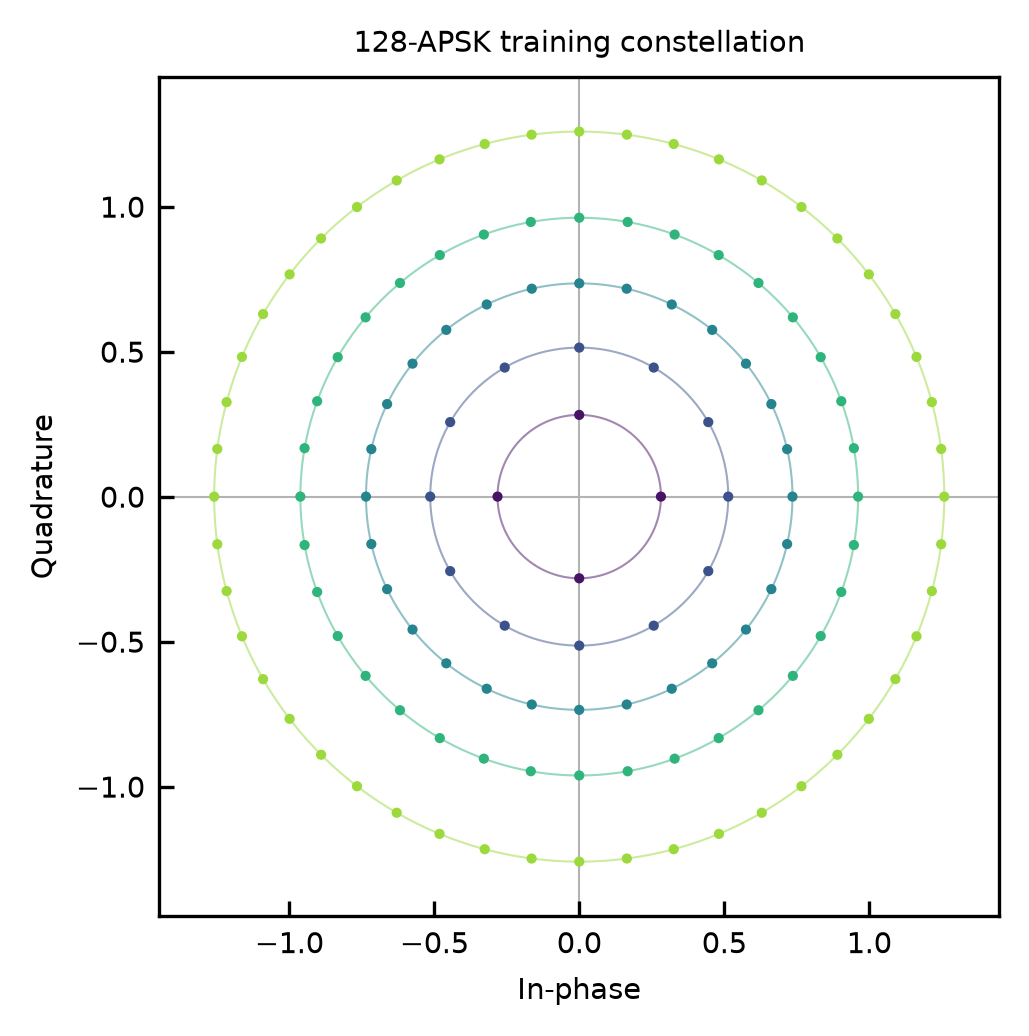

In [3]:
# --- 128-APSK training constellation (supplementary figure) -------------------
import os, sys
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from modules.constellation_diagram import get_constellation

PLOT_PATH = os.path.join(project_root, "data/plots")
FONT = 7
mm = 1 / 25.4

sym = get_constellation("m7_apsk_constellation")._complex_symbols  # unit avg power
radii = np.unique(np.round(np.abs(sym), 6))
ring_idx = np.argmin(np.abs(np.abs(sym)[:, None] - radii[None, :]), axis=1)

plt.rcParams.update({
    "font.size": FONT, "axes.labelsize": FONT, "axes.titlesize": FONT,
    "xtick.labelsize": FONT, "ytick.labelsize": FONT, "legend.fontsize": FONT - 1,
    "font.family": "sans-serif", "font.sans-serif": ["Arial"],
    "figure.dpi": 300, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
})

fig, ax = plt.subplots(figsize=(88 * mm, 88 * mm))
colors = plt.get_cmap("viridis")(np.linspace(0.05, 0.85, len(radii)))

theta = np.linspace(0, 2 * np.pi, 400)
for r, c in zip(radii, colors):
    ax.plot(r * np.cos(theta), r * np.sin(theta), color=c, lw=0.5, alpha=0.5, zorder=1)

for k, (r, c) in enumerate(zip(radii, colors)):
    m = ring_idx == k
    ax.scatter(sym[m].real, sym[m].imag, s=6, color=c, edgecolors="none", zorder=2,
               label=f"$r$ = {r:.2f} ({m.sum()})")

lim = 1.15 * np.abs(sym).max()
ax.axhline(0, color="0.7", lw=0.5, zorder=0)
ax.axvline(0, color="0.7", lw=0.5, zorder=0)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("In-phase")
ax.set_ylabel("Quadrature")
ax.set_title(f"{len(sym)}-APSK training constellation")
fig.tight_layout()
fig.savefig(os.path.join(PLOT_PATH, "supp_128apsk_constellation.png"),
            format="png", bbox_inches="tight")
plt.show()